**Implementacja bibliotek**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel, SequentialFeatureSelector, VarianceThreshold, SelectKBest, mutual_info_classif, SelectFpr, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

**Wczytywanie danych**

In [2]:
X_train = pd.read_csv('artifical_train_data.csv')
X_test = pd.read_csv('artifical_test_data.csv')
y_train = pd.read_csv('artifical_train_labels.csv')

**Wstępne przygotowanie danych**

In [3]:
print("Wymiar danych X_train (wiersze x kolumny):", X_train.shape)
print("Wymiar danych y_train (wiersze x kolumny):", y_train.shape)
print("Wymiar danych X_test (wiersze x kolumny):", X_test.shape)
#zgodne wymiary danych testowych 

Wymiar danych X_train (wiersze x kolumny): (1500, 100)
Wymiar danych y_train (wiersze x kolumny): (1500, 1)
Wymiar danych X_test (wiersze x kolumny): (500, 100)


In [4]:
X_train.info()
y_train.info()
X_test.info()
#mamy same zmienne numeryczne

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 100 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   V1      1500 non-null   int64
 1   V2      1500 non-null   int64
 2   V3      1500 non-null   int64
 3   V4      1500 non-null   int64
 4   V5      1500 non-null   int64
 5   V6      1500 non-null   int64
 6   V7      1500 non-null   int64
 7   V8      1500 non-null   int64
 8   V9      1500 non-null   int64
 9   V10     1500 non-null   int64
 10  V11     1500 non-null   int64
 11  V12     1500 non-null   int64
 12  V13     1500 non-null   int64
 13  V14     1500 non-null   int64
 14  V15     1500 non-null   int64
 15  V16     1500 non-null   int64
 16  V17     1500 non-null   int64
 17  V18     1500 non-null   int64
 18  V19     1500 non-null   int64
 19  V20     1500 non-null   int64
 20  V21     1500 non-null   int64
 21  V22     1500 non-null   int64
 22  V23     1500 non-null   int64
 23  V24     1500

In [5]:
print(X_train[X_train.isnull().any(axis=1)])
print(y_train[y_train.isnull().any(axis=1)])
print(X_test[X_test.isnull().any(axis=1)])
#nie ma w ogole brakow danych

Empty DataFrame
Columns: [V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, V29, V30, V31, V32, V33, V34, V35, V36, V37, V38, V39, V40, V41, V42, V43, V44, V45, V46, V47, V48, V49, V50, V51, V52, V53, V54, V55, V56, V57, V58, V59, V60, V61, V62, V63, V64, V65, V66, V67, V68, V69, V70, V71, V72, V73, V74, V75, V76, V77, V78, V79, V80, V81, V82, V83, V84, V85, V86, V87, V88, V89, V90, V91, V92, V93, V94, V95, V96, V97, V98, V99, V100]
Index: []

[0 rows x 100 columns]
Empty DataFrame
Columns: [Class]
Index: []
Empty DataFrame
Columns: [V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, V29, V30, V31, V32, V33, V34, V35, V36, V37, V38, V39, V40, V41, V42, V43, V44, V45, V46, V47, V48, V49, V50, V51, V52, V53, V54, V55, V56, V57, V58, V59, V60, V61, V62, V63, V64, V65, V66, V67, V68, V69, V70, V71, V72, V73, V74, V75, V76, V77, V78

array([[<Axes: title={'center': 'V1'}>, <Axes: title={'center': 'V2'}>,
        <Axes: title={'center': 'V3'}>, <Axes: title={'center': 'V4'}>,
        <Axes: title={'center': 'V5'}>, <Axes: title={'center': 'V6'}>,
        <Axes: title={'center': 'V7'}>, <Axes: title={'center': 'V8'}>,
        <Axes: title={'center': 'V9'}>, <Axes: title={'center': 'V10'}>],
       [<Axes: title={'center': 'V11'}>, <Axes: title={'center': 'V12'}>,
        <Axes: title={'center': 'V13'}>, <Axes: title={'center': 'V14'}>,
        <Axes: title={'center': 'V15'}>, <Axes: title={'center': 'V16'}>,
        <Axes: title={'center': 'V17'}>, <Axes: title={'center': 'V18'}>,
        <Axes: title={'center': 'V19'}>, <Axes: title={'center': 'V20'}>],
       [<Axes: title={'center': 'V21'}>, <Axes: title={'center': 'V22'}>,
        <Axes: title={'center': 'V23'}>, <Axes: title={'center': 'V24'}>,
        <Axes: title={'center': 'V25'}>, <Axes: title={'center': 'V26'}>,
        <Axes: title={'center': 'V27'}>, <Axe

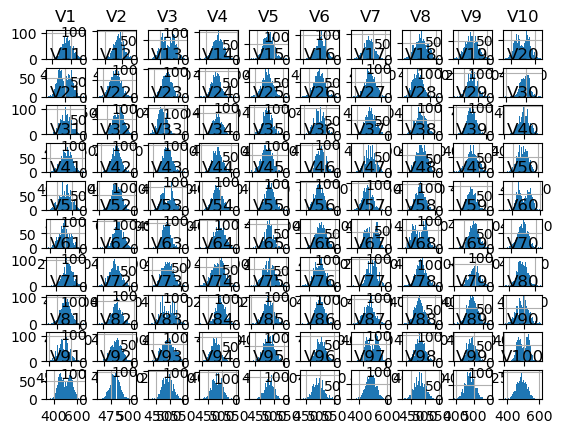

In [6]:
#rozklady zmiennych
X_train.describe()
X_train.hist(sharex = False, sharey = False, bins = 50)

array([[<Axes: title={'center': 'Class'}>]], dtype=object)

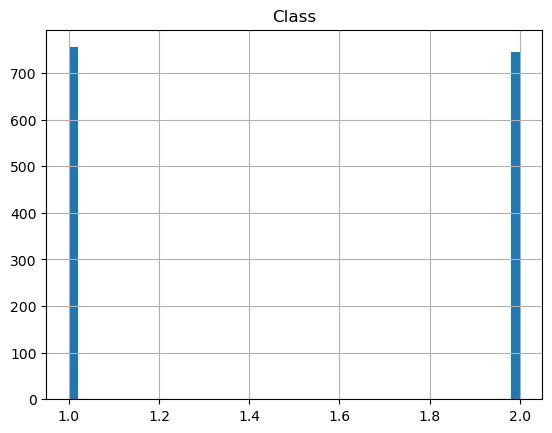

In [7]:
y_train.describe()
y_train.hist(sharex = False, sharey = False, bins = 50)

array([[<Axes: title={'center': 'V1'}>, <Axes: title={'center': 'V2'}>,
        <Axes: title={'center': 'V3'}>, <Axes: title={'center': 'V4'}>,
        <Axes: title={'center': 'V5'}>, <Axes: title={'center': 'V6'}>,
        <Axes: title={'center': 'V7'}>, <Axes: title={'center': 'V8'}>,
        <Axes: title={'center': 'V9'}>, <Axes: title={'center': 'V10'}>],
       [<Axes: title={'center': 'V11'}>, <Axes: title={'center': 'V12'}>,
        <Axes: title={'center': 'V13'}>, <Axes: title={'center': 'V14'}>,
        <Axes: title={'center': 'V15'}>, <Axes: title={'center': 'V16'}>,
        <Axes: title={'center': 'V17'}>, <Axes: title={'center': 'V18'}>,
        <Axes: title={'center': 'V19'}>, <Axes: title={'center': 'V20'}>],
       [<Axes: title={'center': 'V21'}>, <Axes: title={'center': 'V22'}>,
        <Axes: title={'center': 'V23'}>, <Axes: title={'center': 'V24'}>,
        <Axes: title={'center': 'V25'}>, <Axes: title={'center': 'V26'}>,
        <Axes: title={'center': 'V27'}>, <Axe

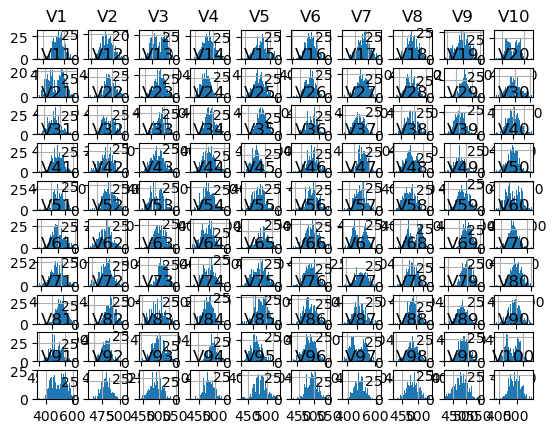

In [8]:
X_test.describe()
X_test.hist(sharex = False, sharey = False, bins = 50)

In [9]:
#nie widac zadnych danych znacznie odstajacych na histogramach 

In [10]:
print(np.sum(y_train.Class == 1.0))
print(np.sum(y_train.Class == 2.0))
#niemal rownoliczne klasy jedynek i dwojek 

755
745


**Właściwy preprocessing**

In [11]:
#stworzymy pipeline, który przeprowadzi nam selekcje zmiennych, oprocz metod poznanych na labolatoriach 
#wybiore kolumny najbardziej skorelowane z y_train oraz wykorzystam metode oparta na entropii

Skalowanie i usuwanie zmiennych o małej wariancji

In [12]:
#tworzymy pipeline'y z preprocessingiem
#danych nie bedziemy imputowac, bo nie ma brakow danych 
#przeskalujemy dane do rozkladu normalnego standardowego wykorzystujac standard scaler
#usuniemy zmienne o niskiej wariancji po preskalowaniu

num_transformer = Pipeline([  
    ('scaler', StandardScaler()),
    ('const', VarianceThreshold(threshold=0.05))
])
num_transformer.fit(X_train)

,steps,"[('scaler', ...), ('const', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,threshold,0.05


In [13]:
X_train_after_VarianceThreshold = pd.DataFrame(num_transformer.transform(X_train), columns=num_transformer.get_feature_names_out())

In [14]:
X_train_after_VarianceThreshold.shape #jak widac zadna ze zmiennych nie miala wariancji mniejszej niz 0.05, wiec nie ma w tym zbiorze danych 
#danych stalych lub nieznacznie rozniacych sie 

(1500, 100)

Skalowanie, usuwanie zmiennych o małej wariancji, selekcja zmiennych, korelacja z zmienna y

In [15]:
#OPIS METOD SLEKCJI
#1. Selekcja oparta na entropii 
#korzystajac z informacji entropijnej jestesmy w stanie wykryc dowolny rodzaj zaleznosci, nie tylko liniowy 

#mutual_info_classif - metoda dzialajaca na informacji wzajemnej, do wykrywania korelacji ale nie tylko liniowych 
#SelectKBest - wybiera wskazana jako parametr ilosc zmiennych, ktore maja najwieksza informacje wzajemna (MI). Wybieramy największą MI, bo takie
#cechy najsilniej wpływają na wynik

#metoda entropijna ocenia każdą cechę osobno

#2. Selekcja za pomocą SelectFromModel - wykorzystujemy informacje z modeli posiadajacych metody feature_importances_ lub coef_
#model z feature_importance w SelectFromModel - Random Forest
#model z coef_ - regresja logistyczna

#randomforest zostawia cechy, które są ważne same w sobie oraz te, które są ważne w zespole z innymi cechami 
#zatem patrzy on na caly zespol cech a nie jedynie na poszczegolne cechy z osobna jak metoda entropijna 

#OPIS METODY CORRELATION
#Metoda SelectFpr (Select False Positive Rate) służy do wyboru kolumn najbardziej skorelowanych z y_train,
#dla każdej zmiennej oblicza p-value (prawdopodobieństwo, że związek zmiennej z X_train z y_train to czysty przypadek).
#f_classif wykonuje jednoczynnikową analizę wariancji (ANOVA F-value), sprawdza srednie przy porownaniu z klasa 0 i 1,
#jeśli średnie są prawie takie same, to cecha jest Słaba/Szumem
#mamy parametr alpha, to jest próg odcięcia dla p-value 
#duze alpha oznacza ze delikatnie filtrujemy z szumow nasze dane
#aceptujemy cechy, które mają alpha szans na bycie przypadkowym szumem

num_transformer = Pipeline([  
    ('scaler', StandardScaler()),
    ('const', VarianceThreshold(threshold=0.05)),
    ('selector', SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=333061))),
    ('correlation', SelectFpr(score_func=f_classif, alpha=0.8))
])
num_transformer.fit(X_train, y_train.Class)

,steps,"[('scaler', ...), ('const', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,threshold,0.05
,estimator,RandomForestC..._state=333061)
,threshold,None
,prefit,False


In [16]:
X_train_after_VarianceThreshold_SelectFromModel = num_transformer.transform(X_train)
X_train_after_VarianceThreshold_SelectFromModel = pd.DataFrame(X_train_after_VarianceThreshold_SelectFromModel, columns=num_transformer.get_feature_names_out())
X_train_after_VarianceThreshold_SelectFromModel.shape

(1500, 19)

In [17]:
#Różne parametry do tego selektora
params = {
    'pre__selector': [
        #metody entropijne
        *[SelectKBest(score_func=mutual_info_classif, k=k) for k in [20, 40, 50, 60, 80, 90]],
        
        #SelectFromModel
        SelectFromModel(LogisticRegression(max_iter=5000, penalty="l1", solver="saga")), #regresja logistyczna z regularyzacja l1
        #las losowy:
        #modelujemy ilosc drzew wzietych do modelu, class_weight zapewnia ze mamy zbalansowana zmienna y - u nas tak jest wiec nie byloby to konieczne
        SelectFromModel(RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=333061)),
        SelectFromModel(RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=333061), threshold='median'), #selektor ustawia 
        #próg dokładnie w środku rankingu ważności, zawsze przepuszcza dalej 50% najlepszych cech 
        SelectFromModel(RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=333061), threshold='mean'), #poprzeczka jaka 
        #musza spelnic zmienne by zostac w modelu to przekroczenie sredniej arytmetycznej z ich waznosci 

        #inna opcja to pominiecie tej kwesti - byc moze najlepszy model nie bedzie uwzglednial selectora
        'passthrough' 
    ],
    'pre__correlation': [SelectFpr(score_func=f_classif, alpha=0.8),
                        SelectFpr(score_func=f_classif, alpha=0.5),
                        'passthrough'
                       ]
}

**Budowanie modelu po preprocessingu**

In [18]:
#POMYSŁ: Zrobimy dla kilku roznych modeli crosswalidacje, dobierzemy ich optymalne parametry preprocessingu jak i samego modelu, a nastepnie 
#polaczymy te modele z odpowiednimi wagami w stackingu 

In [19]:
#parametry tych modeli wraz z balanced accuracy dla kazdego z nich bedziemy przechowywac w listach 
model = []
preprocessing_selector = []
preprocessing_correlation = []
model_params = [] 
bacc = []

***1. Regresja logistyczna***

In [20]:
pipeline_lr = Pipeline([
    ('pre', num_transformer),
    ('lr', LogisticRegression(penalty=None, max_iter=1000, random_state = 333061))
])

In [21]:
#wykonamy najpierw crosswalidacje by dobrac parametry preprocessingu optymalne dla regresji logistycznej

kfold = KFold(n_splits=3, 
              random_state=333061,
              shuffle=True)
grid_pipeline_lr = GridSearchCV(
    pipeline_lr, 
    param_grid=params, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

In [22]:
grid_pipeline_lr.fit(X_train, y_train.Class)

,estimator,Pipeline(step...ate=333061))])
,param_grid,"{'pre__correlation': [SelectFpr(alpha=0.8), SelectFpr(alpha=0.5), ...], 'pre__selector': [SelectKBest(k...02639C5F9300>), SelectKBest(k...02639C5F9300>), ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,steps,"[('scaler', ...), ('const', ...), ...]"


In [23]:
grid_pipeline_lr.best_params_

{'pre__correlation': SelectFpr(alpha=0.8),
 'pre__selector': SelectKBest(k=50,
             score_func=<function mutual_info_classif at 0x000002639C5F9300>)}

In [24]:
balanced_accuracy_score(y_train, grid_pipeline_lr.predict(X_train))

0.6293168585270457

In [25]:
#mamy juz optymalny preprocessing dla regresji, teraz dobierzemy parametry samej regresji
opt_pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('const', VarianceThreshold(threshold=0.05)),
    ('selector', grid_pipeline_lr.best_params_['pre__selector']),
    ('correlation', grid_pipeline_lr.best_params_['pre__correlation']), 
    ('model', LogisticRegression(penalty=None, max_iter=1000, random_state = 333061))
])

In [26]:
params_lr = [
    #Lasso (L1)
    {
        'model__solver': ['liblinear', 'saga'], 
        'model__penalty': ['l1'],
        'model__C': [0.01, 0.1, 1, 10],          
        'model__class_weight': ['balanced']    
    },

    #Ridge (L2) 
    {
        'model__solver': ['lbfgs', 'liblinear'], 
        'model__penalty': ['l2'],
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__class_weight': ['balanced']
    },

    #ElasticNet
    {
        'model__solver': ['saga'],
        'model__penalty': ['elasticnet'],
        'model__C': [0.01, 0.1, 1],
        'model__l1_ratio': [0.2, 0.5, 0.8],  
        'model__class_weight': ['balanced']
    },
    {
        'model__penalty': [None]
    }
]

In [27]:
grid_lr = GridSearchCV(
    opt_pipeline_lr, 
    param_grid=params_lr, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

In [ ]:
grid_lr.fit(X_train, y_train.Class)

In [ ]:
grid_lr.best_params_

In [ ]:
balanced_accuracy_score(y_train, grid_lr.predict(X_train))

In [ ]:
model.append('Regresja logistyczna')
preprocessing_selector.append(grid_pipeline_lr.best_params_['pre__selector'])
preprocessing_correlation.append(grid_pipeline_lr.best_params_['pre__correlation'])
model_params.append(grid_lr.best_params_)
bacc.append(balanced_accuracy_score(y_train, grid_lr.predict(X_train)))
#regresja sobie srednio radzi, raczej dane nie sa liniowe

***2. SVM***

In [289]:
pipeline_svm = Pipeline([
    ('pre', num_transformer),
    ('svm', SVC(kernel = 'rbf', probability=True, random_state = 333061)) #jadro nieliniowe
])

In [290]:
grid_pipeline_svm = GridSearchCV(
    pipeline_svm, 
    param_grid=params, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_pipeline_svm.fit(X_train, y_train.Class)

,estimator,Pipeline(step...ate=333061))])
,param_grid,"{'pre__correlation': [SelectFpr(alpha=0.8), SelectFpr(alpha=0.5), ...], 'pre__selector': [SelectKBest(k...0231763FD260>), SelectKBest(k...0231763FD260>), ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,steps,"[('scaler', ...), ('const', ...), ...]"


In [291]:
grid_pipeline_svm.best_params_

{'pre__correlation': 'passthrough',
 'pre__selector': SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',
                                                  random_state=333061))}

In [292]:
balanced_accuracy_score(y_train, grid_pipeline_svm.predict(X_train))

0.8774523312147207

In [335]:
opt_pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('const', VarianceThreshold(threshold=0.05)),
    ('selector', grid_pipeline_svm.best_params_['pre__selector']),
    ('correlation', grid_pipeline_svm.best_params_['pre__correlation']), 
    ('model', SVC(kernel = 'rbf', probability=True, random_state = 333061)) #probability zeby mozna bylo liczyc predict proba
])

In [358]:
params_svm = {'model__C': [0.1, 0.95, 1, 1.05, 10, 100], 
    'model__gamma': ['scale', #0.25, 0.22, 0.2, 
                     0.1, 0.01] #0.22 jest optymalne, ale wole go nie dawac ze wzgledu na duze ryzyko przeuczenia modelu
}

In [359]:
grid_svm = GridSearchCV(
    opt_pipeline_svm, 
    param_grid=params_svm, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train.Class)

,estimator,Pipeline(step...ate=333061))])
,param_grid,"{'model__C': [0.1, 0.95, ...], 'model__gamma': ['scale', 0.1, ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [360]:
grid_svm.best_params_

{'model__C': 1, 'model__gamma': 0.1}

In [361]:
balanced_accuracy_score(y_train, grid_svm.predict(X_train))

0.9247210987154985

In [482]:
model.append('SVM')
preprocessing_selector.append(grid_pipeline_svm.best_params_['pre__selector'])
preprocessing_correlation.append(grid_pipeline_svm.best_params_['pre__correlation'])
model_params.append(grid_svm.best_params_)
bacc.append(balanced_accuracy_score(y_train, grid_svm.predict(X_train)))

***3. XGBoost - GradientBoosting***

In [363]:
pipeline_gb = Pipeline([
    ('pre', num_transformer),
    ('gb', GradientBoostingClassifier(random_state = 333061))
])

In [364]:
grid_pipeline_gb = GridSearchCV(
    pipeline_gb, 
    param_grid=params, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_pipeline_gb.fit(X_train, y_train.Class)

,estimator,Pipeline(step...ate=333061))])
,param_grid,"{'pre__correlation': [SelectFpr(alpha=0.8), SelectFpr(alpha=0.5), ...], 'pre__selector': [SelectKBest(k...0231763FD260>), SelectKBest(k...0231763FD260>), ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,steps,"[('scaler', ...), ('const', ...), ...]"


In [365]:
grid_pipeline_gb.best_params_

{'pre__correlation': SelectFpr(alpha=0.5),
 'pre__selector': SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',
                                                  random_state=333061))}

In [366]:
balanced_accuracy_score(y_train, grid_pipeline_gb.predict(X_train))

0.8941419618649717

In [368]:
opt_pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('const', VarianceThreshold(threshold=0.05)),
    ('selector', grid_pipeline_gb.best_params_['pre__selector']),
    ('correlation', grid_pipeline_gb.best_params_['pre__correlation']), 
    ('model', GradientBoostingClassifier(random_state = 333061)) 
])

In [475]:
params_gb = {
    'model__learning_rate': [0.01, 0.05],
    'model__n_estimators': [200, 300],
    'model__max_depth': [2, 3],
    'model__subsample': [0.8, 1.0],
    'model__min_samples_leaf': [5, 10]
} #parametry dobrane tak by nie bylo duzego przeuczenia (BACC zbyt wysokie)

In [476]:
grid_gb = GridSearchCV(
    opt_pipeline_gb, 
    param_grid=params_gb, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train.Class)

,estimator,Pipeline(step...ate=333061))])
,param_grid,"{'model__learning_rate': [0.01, 0.05], 'model__max_depth': [2, 3], 'model__min_samples_leaf': [5, 10], 'model__n_estimators': [200, 300], ...}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [477]:
grid_gb.best_params_

{'model__learning_rate': 0.05,
 'model__max_depth': 3,
 'model__min_samples_leaf': 5,
 'model__n_estimators': 300,
 'model__subsample': 0.8}

In [478]:
balanced_accuracy_score(y_train, grid_gb.predict(X_train))

0.9420196453175697

In [483]:
model.append('Gradient Boosting')
preprocessing_selector.append(grid_pipeline_gb.best_params_['pre__selector'])
preprocessing_correlation.append(grid_pipeline_gb.best_params_['pre__correlation'])
model_params.append(grid_gb.best_params_)
bacc.append(balanced_accuracy_score(y_train, grid_gb.predict(X_train)))

***4. KNN***

In [375]:
pipeline_knn = Pipeline([
    ('pre', num_transformer),
    ('knn', KNeighborsClassifier()) #algorytm deterministyczny wiec bez random_state
])

In [376]:
grid_pipeline_knn = GridSearchCV(
    pipeline_knn, 
    param_grid=params, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_pipeline_knn.fit(X_train, y_train.Class)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'pre__correlation': [SelectFpr(alpha=0.8), SelectFpr(alpha=0.5), ...], 'pre__selector': [SelectKBest(k...0231763FD260>), SelectKBest(k...0231763FD260>), ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,steps,"[('scaler', ...), ('const', ...), ...]"


In [377]:
grid_pipeline_knn.best_params_

{'pre__correlation': 'passthrough',
 'pre__selector': SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',
                                                  random_state=333061))}

In [378]:
balanced_accuracy_score(y_train, grid_pipeline_knn.predict(X_train))

0.9233521489843993

In [380]:
opt_pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('const', VarianceThreshold(threshold=0.05)),
    ('selector', grid_pipeline_knn.best_params_['pre__selector']),
    ('correlation', grid_pipeline_knn.best_params_['pre__correlation']), 
    ('model', KNeighborsClassifier()) 
])

In [467]:
params_knn = {
    'model__n_neighbors': [3, 5, 7, 11, 15],
    'model__weights': ['uniform'],
    'model__metric': ['euclidean', 'manhattan']
} #parametry dobrane tak by nie bylo duzego przeuczenia (BACC 1.0)

In [462]:
grid_knn = GridSearchCV(
    opt_pipeline_knn, 
    param_grid=params_knn, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train.Class)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [3, 5, ...], 'model__weights': ['uniform']}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [463]:
grid_knn.best_params_

{'model__metric': 'manhattan',
 'model__n_neighbors': 11,
 'model__weights': 'uniform'}

In [464]:
balanced_accuracy_score(y_train, grid_knn.predict(X_train))

0.9100448908840393

In [484]:
model.append('KNN')
preprocessing_selector.append(grid_pipeline_knn.best_params_['pre__selector'])
preprocessing_correlation.append(grid_pipeline_knn.best_params_['pre__correlation'])
model_params.append(grid_knn.best_params_)
bacc.append(balanced_accuracy_score(y_train, grid_knn.predict(X_train)))

***5. QDA***

In [393]:
pipeline_lda = Pipeline([
    ('pre', num_transformer),
    ('lda', QuadraticDiscriminantAnalysis()) 
])

In [394]:
grid_pipeline_lda = GridSearchCV(
    pipeline_lda, 
    param_grid=params, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_pipeline_lda.fit(X_train, y_train.Class)

,estimator,Pipeline(step...tAnalysis())])
,param_grid,"{'pre__correlation': [SelectFpr(alpha=0.8), SelectFpr(alpha=0.5), ...], 'pre__selector': [SelectKBest(k...0231763FD260>), SelectKBest(k...0231763FD260>), ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,steps,"[('scaler', ...), ('const', ...), ...]"


In [395]:
grid_pipeline_lda.best_params_

{'pre__correlation': SelectFpr(alpha=0.5),
 'pre__selector': SelectKBest(k=20,
             score_func=<function mutual_info_classif at 0x00000231763FD260>)}

In [396]:
balanced_accuracy_score(y_train, grid_pipeline_lda.predict(X_train))

0.7279523534379306

In [397]:
opt_pipeline_lda = Pipeline([
    ('scaler', StandardScaler()),
    ('const', VarianceThreshold(threshold=0.05)),
    ('selector', grid_pipeline_lda.best_params_['pre__selector']),
    ('correlation', grid_pipeline_lda.best_params_['pre__correlation']), 
    ('model', QuadraticDiscriminantAnalysis()) 
])

In [398]:
params_lda = {
    'model__reg_param': [0.0, 0.01, 0.1, 0.5, 0.8]
}

In [399]:
grid_lda = GridSearchCV(
    opt_pipeline_lda, 
    param_grid=params_lda, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_lda.fit(X_train, y_train.Class)

,estimator,Pipeline(step...tAnalysis())])
,param_grid,"{'model__reg_param': [0.0, 0.01, ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [400]:
grid_lda.best_params_

{'model__reg_param': 0.1}

In [401]:
balanced_accuracy_score(y_train, grid_lda.predict(X_train))

0.7167296324281079

In [485]:
model.append('QDA')
preprocessing_selector.append(grid_pipeline_lda.best_params_['pre__selector'])
preprocessing_correlation.append(grid_pipeline_lda.best_params_['pre__correlation'])
model_params.append(grid_lda.best_params_)
bacc.append(balanced_accuracy_score(y_train, grid_lda.predict(X_train)))

***6. Random Forest***

In [404]:
pipeline_rf = Pipeline([
    ('pre', num_transformer),
    ('rf', RandomForestClassifier(random_state = 333061))
])

In [405]:
grid_pipeline_rf = GridSearchCV(
    pipeline_rf, 
    param_grid=params, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_pipeline_rf.fit(X_train, y_train.Class)

,estimator,Pipeline(step...ate=333061))])
,param_grid,"{'pre__correlation': [SelectFpr(alpha=0.8), SelectFpr(alpha=0.5), ...], 'pre__selector': [SelectKBest(k...0231763FD260>), SelectKBest(k...0231763FD260>), ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,steps,"[('scaler', ...), ('const', ...), ...]"


In [406]:
grid_pipeline_rf.best_params_

{'pre__correlation': 'passthrough',
 'pre__selector': SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',
                                                  random_state=333061))}

In [419]:
balanced_accuracy_score(y_train, grid_pipeline_rf.predict(X_train)) #przeuczony!!!

1.0

In [408]:
opt_pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('const', VarianceThreshold(threshold=0.05)),
    ('selector', grid_pipeline_rf.best_params_['pre__selector']),
    ('correlation', grid_pipeline_rf.best_params_['pre__correlation']), 
    ('model', RandomForestClassifier(random_state = 333061))
])

In [468]:
params_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20],
    'model__min_samples_leaf': [10, 12, 15],
    'model__max_features': ['sqrt', 'log2']
} #parametry dobrane tak by nie bylo duzego przeuczenia (BACC 1.0)

In [415]:
grid_rf = GridSearchCV(
    opt_pipeline_rf, 
    param_grid=params_rf, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train.Class)

,estimator,Pipeline(step...ate=333061))])
,param_grid,"{'model__max_depth': [10, 20], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [10, 12, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [416]:
grid_rf.best_params_

{'model__max_depth': 10,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 10,
 'model__n_estimators': 200}

In [417]:
balanced_accuracy_score(y_train, grid_rf.predict(X_train))

0.9260456020267567

In [486]:
model.append('Random Forest')
preprocessing_selector.append(grid_pipeline_rf.best_params_['pre__selector'])
preprocessing_correlation.append(grid_pipeline_rf.best_params_['pre__correlation'])
model_params.append(grid_rf.best_params_)
bacc.append(balanced_accuracy_score(y_train, grid_rf.predict(X_train)))

***7. Extra Trees***

In [420]:
pipeline_et = Pipeline([
    ('pre', num_transformer),
    ('et', ExtraTreesClassifier(random_state = 333061)) 
])

In [421]:
grid_pipeline_et = GridSearchCV(
    pipeline_et, 
    param_grid=params, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_pipeline_et.fit(X_train, y_train.Class)

,estimator,Pipeline(step...ate=333061))])
,param_grid,"{'pre__correlation': [SelectFpr(alpha=0.8), SelectFpr(alpha=0.5), ...], 'pre__selector': [SelectKBest(k...0231763FD260>), SelectKBest(k...0231763FD260>), ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,steps,"[('scaler', ...), ('const', ...), ...]"


In [422]:
grid_pipeline_et.best_params_

{'pre__correlation': 'passthrough',
 'pre__selector': SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',
                                                  random_state=333061))}

In [425]:
balanced_accuracy_score(y_train, grid_pipeline_et.predict(X_train)) #przeuczony!! dobieram takie hiperparametry zeby sie nie przeuczyl

1.0

In [426]:
opt_pipeline_et = Pipeline([
    ('scaler', StandardScaler()),
    ('const', VarianceThreshold(threshold=0.05)),
    ('selector', grid_pipeline_et.best_params_['pre__selector']),
    ('correlation', grid_pipeline_et.best_params_['pre__correlation']), 
    ('model',  ExtraTreesClassifier(random_state = 333061))
])

In [469]:
params_et = {
    'model__min_samples_leaf': [6, 8, 10],
    'model__max_features': ['sqrt', 0.4],
    'model__max_depth': [10, 15, 20], 
    'model__n_estimators': [300, 500]
} #parametry dobrane tak by nie bylo duzego przeuczenia (BACC 1.0)

In [457]:
grid_et = GridSearchCV(
    opt_pipeline_et, 
    param_grid=params_et, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_et.fit(X_train, y_train.Class)

,estimator,Pipeline(step...ate=333061))])
,param_grid,"{'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 0.4], 'model__min_samples_leaf': [6, 8, ...], 'model__n_estimators': [300, 500]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [458]:
grid_et.best_params_

{'model__max_depth': 15,
 'model__max_features': 0.4,
 'model__min_samples_leaf': 6,
 'model__n_estimators': 300}

In [459]:
balanced_accuracy_score(y_train, grid_et.predict(X_train))

0.9453397928796835

In [487]:
model.append('Extra Trees')
preprocessing_selector.append(grid_pipeline_et.best_params_['pre__selector'])
preprocessing_correlation.append(grid_pipeline_et.best_params_['pre__correlation'])
model_params.append(grid_et.best_params_)
bacc.append(balanced_accuracy_score(y_train, grid_et.predict(X_train)))

***8. Naive Bayes***

In [435]:
#stosujemy gaussowskiego naiwnego bayesa, bo mamy przeskalowane dane 
pipeline_nb = Pipeline([
    ('pre', num_transformer),
    ('nb', GaussianNB())
])

In [436]:
grid_pipeline_nb = GridSearchCV(
    pipeline_nb, 
    param_grid=params, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_pipeline_nb.fit(X_train, y_train.Class)

,estimator,Pipeline(step...aussianNB())])
,param_grid,"{'pre__correlation': [SelectFpr(alpha=0.8), SelectFpr(alpha=0.5), ...], 'pre__selector': [SelectKBest(k...0231763FD260>), SelectKBest(k...0231763FD260>), ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,steps,"[('scaler', ...), ('const', ...), ...]"


In [437]:
grid_pipeline_nb.best_params_

{'pre__correlation': 'passthrough', 'pre__selector': 'passthrough'}

In [438]:
balanced_accuracy_score(y_train, grid_pipeline_nb.predict(X_train))

0.6355971376505622

In [439]:
opt_pipeline_nb = Pipeline([
    ('scaler', StandardScaler()),
    ('const', VarianceThreshold(threshold=0.05)),
    ('selector', grid_pipeline_nb.best_params_['pre__selector']),
    ('correlation', grid_pipeline_nb.best_params_['pre__correlation']), 
    ('model', GaussianNB())
])

In [440]:
params_nb = {
    'model__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]
}

In [441]:
grid_nb = GridSearchCV(
    opt_pipeline_nb, 
    param_grid=params_nb, 
    cv=kfold, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_nb.fit(X_train, y_train.Class)

,estimator,Pipeline(step...aussianNB())])
,param_grid,"{'model__var_smoothing': [1e-09, 1e-08, ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [442]:
grid_nb.best_params_

{'model__var_smoothing': 0.01}

In [527]:
balanced_accuracy_score(y_train, grid_nb.predict(X_train)) #to model kwadratowy

0.6355971376505622

In [488]:
model.append('Naive Bayes')
preprocessing_selector.append(grid_pipeline_nb.best_params_['pre__selector'])
preprocessing_correlation.append(grid_pipeline_nb.best_params_['pre__correlation'])
model_params.append(grid_nb.best_params_)
bacc.append(balanced_accuracy_score(y_train, grid_nb.predict(X_train)))

**Wyświetlamy wyniki wszystkich modeli w jednej ramce danych**

In [ ]:
pd.DataFrame({'model': model,
              'selector': preprocessing_selector,
              'correlation': preprocessing_correlation,
              'parametry modelu': model_params,
              'balanced accuracy': bacc
             })

In [ ]:
#modele liniowe: regresje logistyczna i naive bayesa odrzucamy. To nie jest model liniowy, proces uczenia sie danych przebiegl źle dla tych 
#modeli, dostajemy niskie balanced accuracy

**Voting**

In [516]:
estimators_list = [
    ('et', grid_et.best_estimator_), 
    ('gb', grid_gb.best_estimator_),      
    ('svm', grid_svm.best_estimator_),    
    ('knn', grid_knn.best_estimator_),  
    ('rf', grid_rf.best_estimator_),
    ('qda', grid_lda.best_estimator_)
]
weights_list = [6, 5, 4, 4, 4, 1] #wagi dla kazdego z estymatorow, dla qda najmniejsza bo jest najslabsze

In [517]:
voting = VotingClassifier(
    estimators=estimators_list,
    voting='soft', 
    weights=weights_list,
    n_jobs=-1
)

In [518]:
voting.fit(X_train, y_train.Class)

,estimators,"[('et', ...), ('gb', ...), ...]"
,voting,'soft'
,weights,"[6, 5, ...]"
,n_jobs,-1
,flatten_transform,True
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,threshold,0.05
,estimator,RandomForestC..._state=333061)


In [519]:
balanced_accuracy_score(y_train, voting.predict(X_train)) 

0.9426730076892307

**Stacking**

In [521]:
stacking = StackingClassifier(
    estimators=estimators_list,
    final_estimator=LogisticRegression(random_state = 333061),
    cv=5,   
    n_jobs=-1
)

In [523]:
stacking.fit(X_train, y_train.Class)

,estimators,"[('et', ...), ('gb', ...), ...]"
,final_estimator,LogisticRegre..._state=333061)
,cv,5
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,copy,True
,with_mean,True
,with_std,True
,threshold,0.05


In [524]:
balanced_accuracy_score(y_train, stacking.predict(X_train)) 

0.928676830081337

**Wektor prawdopodobieństw przynależności do klasy 1 dla obserwacji ze zbioru
testowego**

In [ ]:
##OSTATECZNY MODEL##
#Voting

In [525]:
#w pipeline znajduje sie ostateczny model przez nas wybrany, mamy klasy 1 i 2, przynaleznosc do klasy 1 to pierwsza kolumna
y_pred_proba = voting.predict_proba(X_test)[:, 0]

In [526]:
pd.DataFrame(y_pred_proba).to_csv('333061_artifical_prediction.txt', index=False, header=False)